# Phase 1 — CRNN Training on Hindi Handwritten Words
## VGG16 (frozen) + BiLSTM + CTC Loss
### Dataset: HindiSeg via /kaggle/input/datasets/sabarinathan/handwritten-hindi-word-recognition

In [1]:
# ── CELL 1: Check GPU ─────────────────────────────────────────────
import torch
print('CUDA available :', torch.cuda.is_available())
print('GPU            :', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NONE — enable GPU in Settings > Accelerator')
print('PyTorch        :', torch.__version__)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device         :', DEVICE)

CUDA available : True
GPU            : Tesla T4
PyTorch        : 2.10.0+cu128
Device         : cuda


In [41]:
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']

In [2]:
# ── CELL 2: Explore exact folder structure ────────────────────────
# Run this first so we know EXACTLY where everything is
import os
from pathlib import Path

ROOT = Path('/kaggle/input/datasets/sabarinathan/handwritten-hindi-word-recognition')

print('ROOT exists:', ROOT.exists())
print()
print('Top-level contents:')
for item in sorted(ROOT.iterdir()):
    print(f'  {"DIR" if item.is_dir() else "FILE"}  {item.name}')

print()
# Go one level deeper
for item in sorted(ROOT.iterdir()):
    if item.is_dir():
        print(f'Inside {item.name}/')
        for sub in sorted(item.iterdir())[:10]:
            print(f'    {"DIR" if sub.is_dir() else "FILE"}  {sub.name}')
        print()

ROOT exists: True

Top-level contents:
  DIR  HindiSeg
  FILE  test.csv
  FILE  test.txt
  FILE  train.csv
  FILE  train.txt
  FILE  val.csv
  FILE  val.txt

Inside HindiSeg/
    DIR  HindiSeg



In [3]:
# ── CELL 3: Find CSV files and peek inside ────────────────────────
import pandas as pd

# Find all CSV files
csv_files = list(ROOT.rglob('*.csv'))
print(f'Found {len(csv_files)} CSV files:')
for f in csv_files:
    print(f'  {f}')

print()
# Peek at the first one
if csv_files:
    df = pd.read_csv(csv_files[0])
    print(f'Columns: {list(df.columns)}')
    print(f'Shape  : {df.shape}')
    print()
    print('First 5 rows:')
    print(df.head())

Found 3 CSV files:
  /kaggle/input/datasets/sabarinathan/handwritten-hindi-word-recognition/val.csv
  /kaggle/input/datasets/sabarinathan/handwritten-hindi-word-recognition/train.csv
  /kaggle/input/datasets/sabarinathan/handwritten-hindi-word-recognition/test.csv

Columns: ['file_name', 'text']
Shape  : (12708, 2)

First 5 rows:
                   file_name    text
0  HindiSeg/val/3/165/18.jpg  शरावती
1  HindiSeg/val/12/43/27.jpg     जोख
2   HindiSeg/val/12/1/36.jpg  बहादुर
3  HindiSeg/val/3/142/25.jpg   बकवास
4  HindiSeg/val/3/169/39.jpg      मॉ


Raw path from CSV : HindiSeg/val/3/165/18.jpg
Label             : शरावती
Full path tried   : /kaggle/input/datasets/sabarinathan/handwritten-hindi-word-recognition/HindiSeg/val/3/165/18.jpg
Exists            : False
Trying alternative: /kaggle/input/datasets/sabarinathan/handwritten-hindi-word-recognition/HindiSeg/HindiSeg/val/3/165/18.jpg
Exists            : True


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2366 (\N{DEVANAGARI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 2357 (\N{DEVANAGARI LETTER VA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/li

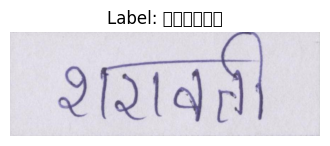

Image loaded successfully!


In [16]:
# ── CELL 4: Verify one image loads correctly ──────────────────────
from PIL import Image
import matplotlib.pyplot as plt

# Take first row of first CSV and try to open that image
df_sample = pd.read_csv(csv_files[0])
path_col  = df_sample.columns[0]
label_col = df_sample.columns[1]

sample_row = df_sample.iloc[0]
raw_path   = sample_row[path_col]
label      = sample_row[label_col]

print(f'Raw path from CSV : {raw_path}')
print(f'Label             : {label}')

# Try joining with ROOT
full_path = ROOT / raw_path
print(f'Full path tried   : {full_path}')
print(f'Exists            : {full_path.exists()}')

# If not found, use the confirmed doubled HindiSeg structure
if not full_path.exists():
    full_path2 = ROOT / 'HindiSeg' / raw_path
    print(f'Trying alternative: {full_path2}')
    print(f'Exists            : {full_path2.exists()}')
    if full_path2.exists():
        full_path = full_path2

if full_path.exists():
    img = Image.open(full_path)
    plt.figure(figsize=(4,2))
    plt.imshow(img, cmap='gray')
    plt.title(f'Label: {label}')
    plt.axis('off')
    plt.show()
    print('Image loaded successfully!')
else:
    print('ERROR: Image not found. Share the output above and we will fix the path.')

In [51]:
# ── CELL 5: Configuration ─────────────────────────────────────────
# ONLY edit this cell
# After running Cell 4, you know the correct base path.
# Set BASE_DIR to whatever made the image load in Cell 4.

BASE_DIR  = ROOT / 'HindiSeg' / 'HindiSeg'   # for images

TRAIN_CSV = ROOT / 'train.csv'                # CSVs live directly under ROOT
VAL_CSV   = ROOT / 'val.csv'
TEST_CSV  = ROOT / 'test.csv'

OUTPUT_DIR   = Path('/kaggle/working')
CKPT_DIR     = OUTPUT_DIR / 'checkpoints'
MODEL_PATH   = OUTPUT_DIR / 'crnn_hindi_best.pth'
VOCAB_PATH   = OUTPUT_DIR / 'vocab.txt'
CKPT_DIR.mkdir(exist_ok=True)

IMG_HEIGHT     = 64
IMG_WIDTH      = 256
BATCH_SIZE     = 64
EPOCHS         = 40
LR             = 1e-3
MAX_LABEL_LEN  = 20
CHECKPOINT_EVERY = 5   # save checkpoint every N epochs
TRAIN_SUBSAMPLE  = None  # set to None to use all 92k

print('Configuration ready.')
print(f'Train CSV exists : {TRAIN_CSV.exists()}')
print(f'Val   CSV exists : {VAL_CSV.exists()}')
print(f'Test  CSV exists : {TEST_CSV.exists()}')

Configuration ready.
Train CSV exists : True
Val   CSV exists : True
Test  CSV exists : True


In [20]:
print(csv_files)

[PosixPath('/kaggle/input/datasets/sabarinathan/handwritten-hindi-word-recognition/val.csv'), PosixPath('/kaggle/input/datasets/sabarinathan/handwritten-hindi-word-recognition/train.csv'), PosixPath('/kaggle/input/datasets/sabarinathan/handwritten-hindi-word-recognition/test.csv')]


In [22]:
# ── CELL 6: Imports ───────────────────────────────────────────────
import os, csv, random, time
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

import matplotlib.pyplot as plt
print('Imports done.')

Imports done.


In [23]:
# ── CELL 7: Load Labels + Build Vocabulary ────────────────────────
def load_pairs(csv_path, base_dir):
    pairs = []
    df = pd.read_csv(csv_path)
    path_col  = df.columns[0]
    label_col = df.columns[1]
    
    for _, row in df.iterrows():
        raw   = str(row[path_col]).strip()
        label = str(row[label_col]).strip()
        
        # try direct join
        img_path = base_dir / raw
        
        # fallback: strip leading folder name
        if not img_path.exists():
            parts = Path(raw).parts
            img_path = base_dir / Path(*parts[1:]) if len(parts) > 1 else img_path
        
        if img_path.exists() and label:
            pairs.append((str(img_path), label))
    
    return pairs

print('Loading CSVs...')
train_pairs = load_pairs(TRAIN_CSV, BASE_DIR)
val_pairs   = load_pairs(VAL_CSV,   BASE_DIR)
test_pairs  = load_pairs(TEST_CSV,  BASE_DIR)

print(f'Train : {len(train_pairs)} samples')
print(f'Val   : {len(val_pairs)} samples')
print(f'Test  : {len(test_pairs)} samples')

# Build vocabulary from all labels
all_chars = set()
for _, label in train_pairs + val_pairs + test_pairs:
    all_chars.update(list(label))

vocab    = ['<BLANK>'] + sorted(list(all_chars))
char2idx = {c: i for i, c in enumerate(vocab)}
idx2char = {i: c for i, c in enumerate(vocab)}
NUM_CLASSES = len(vocab)

with open(VOCAB_PATH, 'w', encoding='utf-8') as f:
    f.write('\n'.join(vocab))

print(f'\nVocabulary: {NUM_CLASSES} characters')
print(f'Saved to  : {VOCAB_PATH}')

Loading CSVs...
Train : 69853 samples
Val   : 12708 samples
Test  : 12869 samples

Vocabulary: 109 characters
Saved to  : /kaggle/working/vocab.txt


In [53]:
# ── CELL 8: Dataset + DataLoader ─────────────────────────────────
class DevanagariDataset(Dataset):
    def __init__(self, pairs, char2idx,
                 img_h=32, img_w=128,
                 max_label_len=20, subsample=None):
        
        self.pairs         = pairs[:subsample] if subsample else pairs
        self.char2idx      = char2idx
        self.max_label_len = max_label_len
        
        # Training transform (with augmentation)
        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=3),
            transforms.Resize((img_h, img_w)),
            transforms.RandomAffine(degrees=3, translate=(0.05, 0.05), shear=3),
            transforms.ColorJitter(brightness=0.3, contrast=0.3),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std =[0.229, 0.224, 0.225])
        ])
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        img_path, label = self.pairs[idx]
        try:
            img = Image.open(img_path).convert('RGB')
        except:
            img = Image.new('RGB', (128, 32), (255,255,255))
        
        img     = self.transform(img)
        encoded = [self.char2idx.get(c, 0) for c in label[:self.max_label_len]]
        length  = len(encoded)
        encoded += [0] * (self.max_label_len - length)
        
        return img, torch.tensor(encoded, dtype=torch.long), torch.tensor(length)

train_ds = DevanagariDataset(train_pairs, char2idx,
                              IMG_HEIGHT, IMG_WIDTH,
                              MAX_LABEL_LEN, TRAIN_SUBSAMPLE)
val_ds   = DevanagariDataset(val_pairs, char2idx,
                              IMG_HEIGHT, IMG_WIDTH, MAX_LABEL_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')

Train batches : 1092
Val   batches : 199


In [28]:
import matplotlib
matplotlib.rcParams['font.family'] = 'Noto Sans Devanagari'

In [56]:
import warnings
warnings.filterwarnings('ignore', message='.*Glyph.*')
warnings.filterwarnings('ignore', message='.*Devanagari.*')

Labels for the 10 samples:
  1. डाली
  2. महिलाओ
  3. इस्मत
  4. लाखन
  5. अंतर
  6. अम्माजी
  7. ऐंठने
  8. ख़ान
  9. यथार्थ
  10. सामाग्री


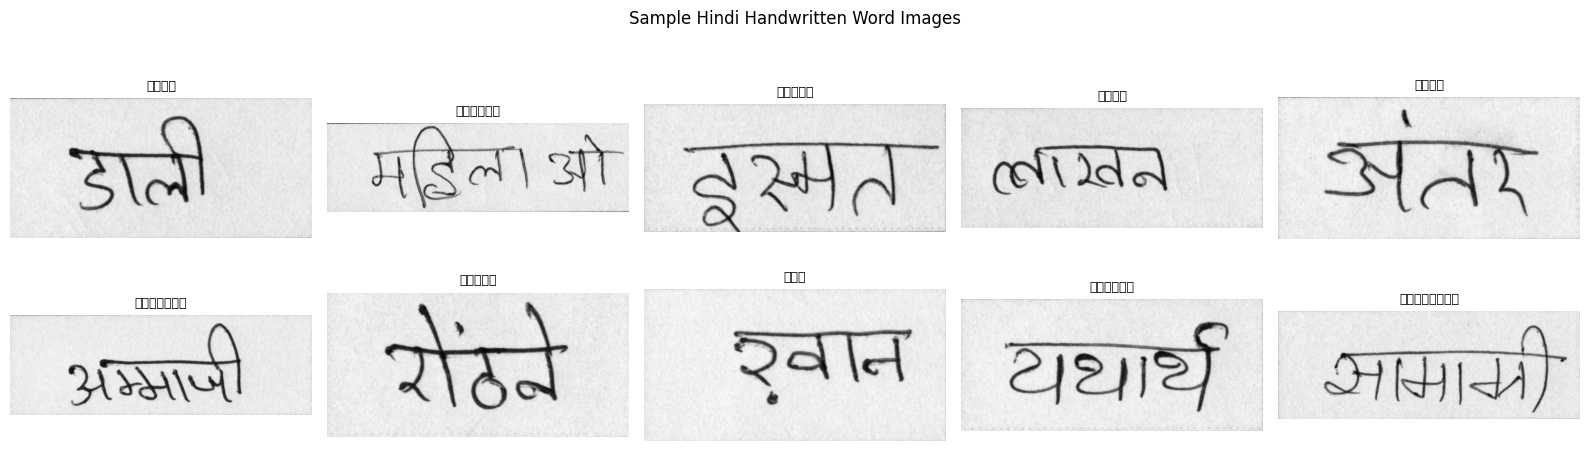

If images show correctly, proceed to Cell 10.


In [58]:
# ── CELL 9: Preview 10 training images ───────────────────────────
samples = random.sample(train_pairs, 10)
fig, axes = plt.subplots(2, 5, figsize=(16, 5))

for ax, (path, label) in zip(axes.flat, samples):
    try:
        img = Image.open(path).convert('L')
        ax.imshow(img, cmap='gray')
        ax.set_title(label, fontsize=9)
    except Exception as e:
        ax.set_title(f'Error', fontsize=7)
    ax.axis('off')

print("Labels for the 10 samples:")
for i, (path, label) in enumerate(samples):
    print(f"  {i+1}. {label}")
plt.suptitle('Sample Hindi Handwritten Word Images')
plt.tight_layout()
plt.show()
print('If images show correctly, proceed to Cell 10.')

In [31]:
import matplotlib
matplotlib.rcParams['font.family'] = 'Noto Sans Devanagari'

In [59]:
# Cell 10
class CRNN(nn.Module):
    def __init__(self, num_classes, hidden_size=256):
        super().__init__()

        # VGG16 pretrained — unfreeze from block 3 onwards
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        self.cnn = vgg.features

        for i, layer in enumerate(self.cnn):
            if i < 14:   # freeze blocks 1 & 2 (low-level edge detectors)
                for p in layer.parameters():
                    p.requires_grad = False
            else:        # unfreeze blocks 3, 4, 5 — learn Devanagari features
                for p in layer.parameters():
                    p.requires_grad = True

        # Collapse height → sequence
        self.pool = nn.AdaptiveAvgPool2d((1, None))

        # BiLSTM
        self.rnn = nn.LSTM(
            input_size    = 512,
            hidden_size   = hidden_size,
            num_layers    = 2,
            bidirectional = True,
            batch_first   = False,
            dropout       = 0.3
        )

        # Output projection
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        f = self.cnn(x)          # [B, 512, H', W']
        f = self.pool(f)         # [B, 512, 1, W']
        b, c, h, w = f.size()
        f = f.squeeze(2)         # [B, 512, W']
        f = f.permute(2, 0, 1)   # [W', B, 512]
        r, _ = self.rnn(f)       # [W', B, 512]
        out = self.fc(r)         # [W', B, num_classes]
        return torch.nn.functional.log_softmax(out, dim=2)


model = CRNN(num_classes=NUM_CLASSES).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total:,}')
print(f'Trainable       : {trainable:,}')
print(f'Frozen (VGG16 blocks 1-2) : {total-trainable:,}')

Total params    : 17,924,525
Trainable       : 16,779,117
Frozen (VGG16 blocks 1-2) : 1,145,408


In [46]:
# ── CELL 11: CTC Decoder + Metrics ───────────────────────────────
def ctc_decode(output, idx2char):
    preds = output.argmax(dim=2).permute(1, 0)  # [B, T]
    decoded = []
    for seq in preds:
        chars, prev = [], None
        for idx in seq.tolist():
            if idx != prev and idx != 0:
                chars.append(idx2char.get(idx, ''))
            prev = idx
        decoded.append(''.join(chars))
    return decoded

def word_accuracy(preds, targets):
    return sum(p == t for p, t in zip(preds, targets)) / len(targets)

def char_error_rate(preds, targets):
    total, errors = 0, 0
    for p, t in zip(preds, targets):
        total  += len(t)
        errors += sum(1 for a, b in zip(p.ljust(len(t)), t) if a != b)
        errors += abs(len(p) - len(t))
    return errors / max(total, 1)

print('Decoder and metrics ready.')

Decoder and metrics ready.


In [60]:
# ── CELL 12: Training + Validation Functions ──────────────────────
criterion = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)

# Lower LR for the unfrozen CNN layers, normal LR for RNN+FC
optimizer = optim.Adam([
    {'params': [p for p in model.cnn.parameters() if p.requires_grad], 'lr': 1e-5},
    {'params': model.rnn.parameters(), 'lr': 1e-3},
    {'params': model.fc.parameters(),  'lr': 1e-3},
])

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5
)

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for i, (imgs, labels, lengths) in enumerate(loader):
        imgs = imgs.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        T, B = out.size(0), out.size(1)
        input_lens = torch.full((B,), T, dtype=torch.long)
        flat = []
        for j in range(B):
            flat.extend(labels[j][:lengths[j].item()].tolist())
        flat = torch.tensor(flat, dtype=torch.long)
        loss = criterion(out, flat, input_lens, lengths)
        if not (torch.isnan(loss) or torch.isinf(loss)):
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total_loss += loss.item()
        if (i + 1) % 100 == 0:
            print(f'    Batch {i+1}/{len(loader)}  loss={loss.item():.4f}')
    return total_loss / len(loader)

def validate_epoch(model, loader, criterion, idx2char, device):
    model.eval()
    total_loss, all_preds, all_targets = 0, [], []
    with torch.no_grad():
        for imgs, labels, lengths in loader:
            imgs = imgs.to(device)
            out  = model(imgs)
            T, B = out.size(0), out.size(1)
            input_lens = torch.full((B,), T, dtype=torch.long)
            flat, words = [], []
            for j in range(B):
                l = lengths[j].item()
                flat.extend(labels[j][:l].tolist())
                words.append(''.join(idx2char.get(labels[j][k].item(), '')
                                     for k in range(l)))
            flat = torch.tensor(flat, dtype=torch.long)
            loss = criterion(out, flat, input_lens, lengths)
            if not torch.isnan(loss):
                total_loss += loss.item()
            all_preds.extend(ctc_decode(out, idx2char))
            all_targets.extend(words)
    
    acc = word_accuracy(all_preds, all_targets)
    cer = char_error_rate(all_preds, all_targets)
    
    # show 5 sample predictions
    print('  Sample predictions:')
    for p, t in zip(all_preds[:5], all_targets[:5]):
        print(f'    {"✓" if p==t else "✗"}  true={t}  pred={p}')
    
    return total_loss / len(loader), acc, cer

print('Training functions ready.')

Training functions ready.


In [63]:
# ── Load Phase 1 checkpoint ───────────────────────────────────────
checkpoint = torch.load('/kaggle/working/crnn_hindi_best.pth', map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
optimizer.load_state_dict(checkpoint['optimizer'])
print(f"Resumed from epoch {checkpoint['epoch']}  val_acc={checkpoint['val_acc']*100:.2f}%")

Resumed from epoch 20  val_acc=6.53%


In [ ]:
# ── CELL 13: TRAINING LOOP ────────────────────────────────────────
# This is the long cell. Expected: 2-4 hours on T4 GPU.
# Do NOT close the browser tab.
# Checkpoints save every 5 epochs so crashes don't lose everything.

history = {'train_loss':[], 'val_loss':[], 'val_acc':[], 'val_cer':[]}
best_acc   = 0.0
best_epoch = 0

print('=' * 55)
print(f' PHASE 1 TRAINING START')
print(f' Epochs      : {EPOCHS}')
print(f' Train size  : {len(train_ds)}')
print(f' Batch size  : {BATCH_SIZE}')
print(f' Device      : {DEVICE}')
print(f' Checkpoint  : every {CHECKPOINT_EVERY} epochs → {CKPT_DIR}')
print('=' * 55)



for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    print(f'\n── Epoch {epoch}/{EPOCHS} ──────────────────────────────')
    
    train_loss              = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_acc, val_cer = validate_epoch(model, val_loader, criterion, idx2char, DEVICE)
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_cer'].append(val_cer)
    
    elapsed = time.time() - t0
    lr_now  = optimizer.param_groups[0]['lr']
    
    print(f'  train_loss : {train_loss:.4f}')
    print(f'  val_loss   : {val_loss:.4f}')
    print(f'  val_acc    : {val_acc*100:.2f}%')
    print(f'  val_cer    : {val_cer:.4f}')
    print(f'  lr         : {lr_now:.6f}')
    print(f'  time       : {elapsed:.0f}s')
    
    # ── Save BEST model ──────────────────────────────────────────
    if val_acc > best_acc:
        best_acc   = val_acc
        best_epoch = epoch
        torch.save({
            'epoch'       : epoch,
            'model_state' : model.state_dict(),
            'optimizer'   : optimizer.state_dict(),
            'val_acc'     : val_acc,
            'val_cer'     : val_cer,
            'num_classes' : NUM_CLASSES,
            'vocab'       : vocab,
            'history'     : history,
        }, MODEL_PATH)
        print(f'  ★ BEST saved  epoch={epoch}  acc={val_acc*100:.2f}%')
    
    # ── Save PERIODIC checkpoint ──────────────────────────────────
    if epoch % CHECKPOINT_EVERY == 0:
        ckpt = CKPT_DIR / f'ckpt_epoch{epoch:03d}_acc{val_acc*100:.1f}.pth'
        torch.save({
            'epoch'       : epoch,
            'model_state' : model.state_dict(),
            'optimizer'   : optimizer.state_dict(),
            'history'     : history,
            'num_classes' : NUM_CLASSES,
            'vocab'       : vocab,
        }, ckpt)
        print(f'  ✓ Checkpoint saved → {ckpt.name}')

print(f'\n{"="*55}')
print(f' TRAINING COMPLETE')
print(f' Best accuracy : {best_acc*100:.2f}% at epoch {best_epoch}')
print(f' Best model    : {MODEL_PATH}')
print(f'{"="*55}')

 PHASE 1 TRAINING START
 Epochs      : 40
 Train size  : 69853
 Batch size  : 64
 Device      : cuda
 Checkpoint  : every 5 epochs → /kaggle/working/checkpoints

── Epoch 1/40 ──────────────────────────────
    Batch 100/1092  loss=1.7571
    Batch 200/1092  loss=1.4787
    Batch 300/1092  loss=1.3554
    Batch 400/1092  loss=0.9503
    Batch 500/1092  loss=1.0002
    Batch 600/1092  loss=0.9050
    Batch 700/1092  loss=0.8708
    Batch 800/1092  loss=1.0685
    Batch 900/1092  loss=0.7756
    Batch 1000/1092  loss=0.6827
  Sample predictions:
    ✗  true=शरावती  pred=शरावारी
    ✓  true=जोख  pred=जोख
    ✗  true=बहादुर  pred=बहदु
    ✗  true=बकवास  pred=बकवाूर
    ✗  true=मॉ  pred=मँ
  train_loss : 1.1750
  val_loss   : 1.0569
  val_acc    : 16.78%
  val_cer    : 0.7309
  lr         : 0.000010
  time       : 434s
  ★ BEST saved  epoch=1  acc=16.78%

── Epoch 2/40 ──────────────────────────────
    Batch 100/1092  loss=0.6484
    Batch 200/1092  loss=0.6610
    Batch 300/1092  loss=0.7

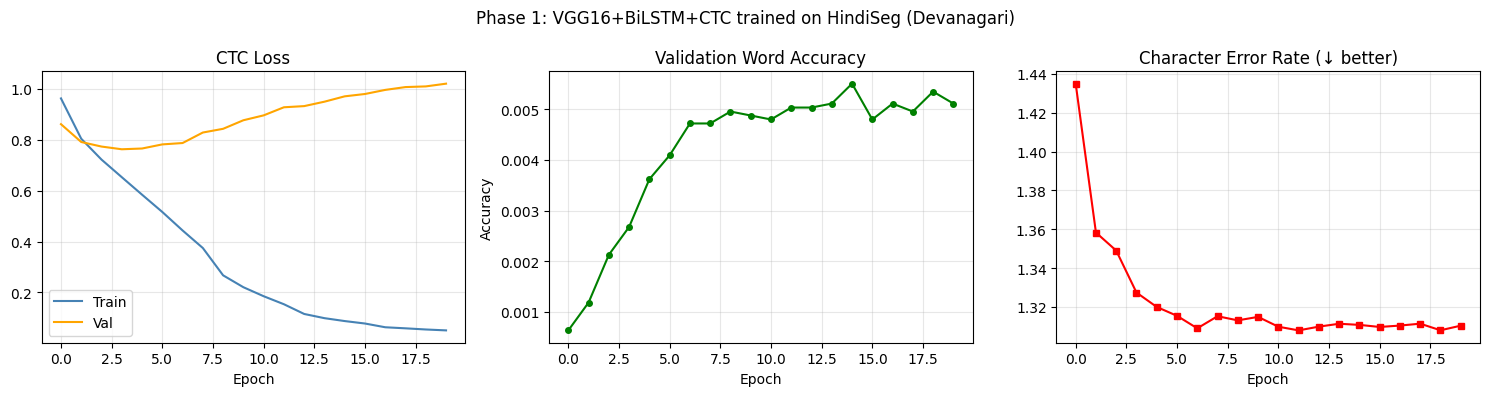

Saved: phase1_curves.png


In [42]:
# ── CELL 14: Plot Training Curves ────────────────────────────────
# Copy these charts into your report

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train', color='steelblue')
axes[0].plot(history['val_loss'],   label='Val',   color='orange')
axes[0].set_title('CTC Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['val_acc'], color='green', marker='o', ms=4)
axes[1].set_title('Validation Word Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(alpha=0.3)

axes[2].plot(history['val_cer'], color='red', marker='s', ms=4)
axes[2].set_title('Character Error Rate (↓ better)')
axes[2].set_xlabel('Epoch')
axes[2].grid(alpha=0.3)

plt.suptitle('Phase 1: VGG16+BiLSTM+CTC trained on HindiSeg (Devanagari)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'phase1_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: phase1_curves.png')

/tmp/ipykernel_58/1310169168.py:28: UserWarning: Glyph 2342 (\N{DEVANAGARI LETTER DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/1310169168.py:28: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_58/1310169168.py:28: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/1310169168.py:28: UserWarning: Glyph 2357 (\N{DEVANAGARI LETTER VA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/1310169168.py:28: UserWarning: Glyph 2306 (\N{DEVANAGARI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/1310169168.py:28: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/1310169168.py:28: UserWarning: Glyph 2370 (\N{DEVANAGARI VOWEL SIGN UU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipyk

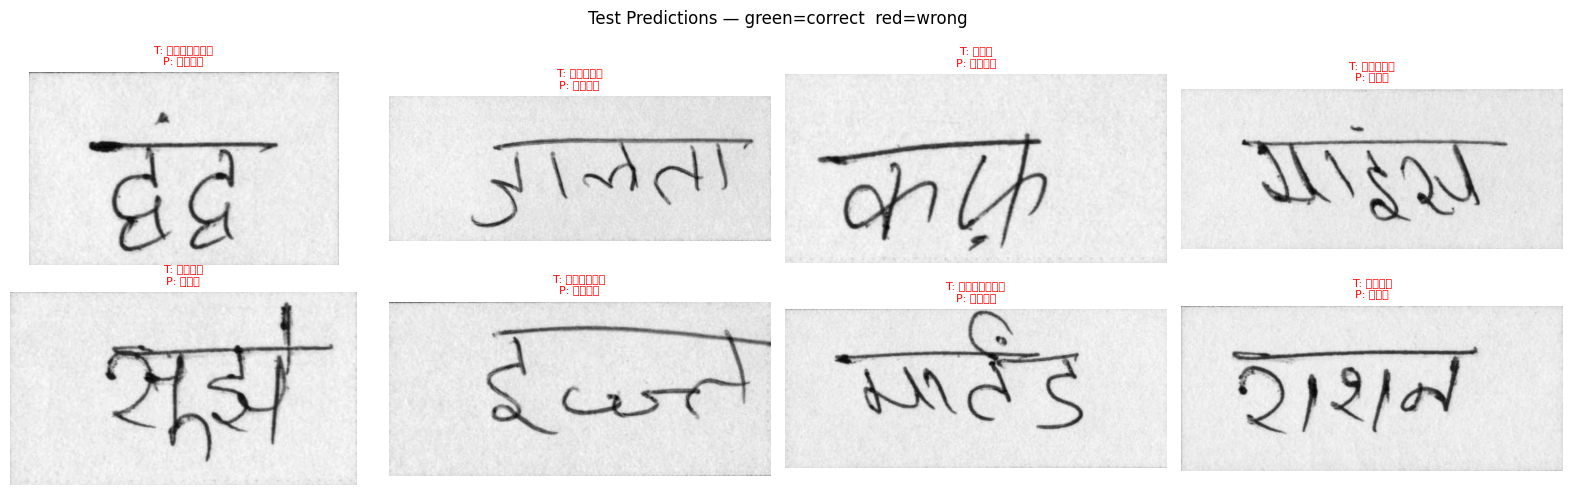


Phase 1 complete!
Download these files from the Output panel on the right:
  crnn_hindi_best.pth  (97.4 MB)
  vocab.txt
You will need both for Phase 2 fine-tuning on Nepali data.


In [43]:
# ── CELL 15: Test on sample images ───────────────────────────────
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.eval()

tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

samples = random.sample(test_pairs, 8)
fig, axes = plt.subplots(2, 4, figsize=(16, 5))

with torch.no_grad():
    for ax, (path, true_label) in zip(axes.flat, samples):
        img    = Image.open(path).convert('RGB')
        tensor = tf(img).unsqueeze(0).to(DEVICE)
        out    = model(tensor)
        pred   = ctc_decode(out, idx2char)[0]
        color  = 'green' if pred == true_label else 'red'
        ax.imshow(Image.open(path).convert('L'), cmap='gray')
        ax.set_title(f'T: {true_label}\nP: {pred}', color=color, fontsize=8)
        ax.axis('off')

plt.suptitle('Test Predictions — green=correct  red=wrong')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'phase1_test_preds.png', dpi=150)
plt.show()

print()
print('Phase 1 complete!')
print('Download these files from the Output panel on the right:')
print(f'  crnn_hindi_best.pth  ({os.path.getsize(MODEL_PATH)/1e6:.1f} MB)')
print(f'  vocab.txt')
print('You will need both for Phase 2 fine-tuning on Nepali data.')